# Figure 2A

### Species clustering UHVDB

In [ ]:
%%bash
### Run vClust on genomovar reps and cluster with MCL

# mkdir -p vclust
# cd vclust

# # cluster UHVDB at 95% ANI and 85% AF
# vclust \
#     prefilter \
#     --in ../figure_1/uhvdb.vclust_genomovars_reps.fna.gz \
#     --out uhvdb.vclust_votu_prefilter.txt \
#     --threads 48 \
#     --min-ident 0.95

# vclust \
#     align \
#     --in ../figure_1/uhvdb.vclust_genomovars_reps.fna.gz \
#     --out uhvdb.vclust_votu_ani.tsv \
#     --filter uhvdb.vclust_votu_prefilter.txt \
#     --threads 48 \
#     --out-ani 0.95 \
#     --out-qcov 0.85

# csvtk cut \
#     uhvdb.vclust_votu_ani.tsv \
#     --tabs \
#     --delete-header \
#     --fields query,reference,gani \
#     --out-file uhvdb.vclust_mcl.tsv

# mcl \
#     vclust/uhvdb.vclust_final_mcl.tsv \
#     --abc \
#     -sort revsize \
#     -te 32 \
#     -o vclust/uhvdb.vclust.mcl

In [ ]:
### functions to load mcl clusters and metadata
# new uhgv votu selection script
import polars as pl

def load_mcl_clusters(mcl, unique):
    # assign sequences to mcl clusters
    clusters = {}

    cluster_id = 0
    with open(mcl, 'r') as mcl_file:
        for line in mcl_file:
            cluster_id += 1
            for node in line.strip().split():
                clusters[node] = cluster_id

    # assign unclustered sequences to their own cluster
    with open(unique, 'r') as unique_file:
        for line in unique_file:
            sequence = line.strip().split()[0]
            if sequence not in clusters:
                cluster_id += 1
                clusters[sequence] = cluster_id

    print("Number of clusters:", cluster_id)

    return clusters

def load_metadata(mine_report, uhgv_metadata, clusters):
    mine_report = (
        # load mine report and join with uhvdb metadata
        pl.read_csv(mine_report, separator='\t', columns=['seq_name', 'contig_length', 'proviral_length', 'viral_genes', 'completeness_method_2'], ignore_errors=True)
            .join(
                pl.read_csv(uhgv_metadata, separator='\t', columns=['uhgv_genome', 'genome_length', 'checkv_viral_markers', 'checkv_completeness_method'], ignore_errors=True),
                how='full', left_on='seq_name', right_on='uhgv_genome', suffix='_uhgv',
            )
            # retain only sequences that are in clusters
            .filter(
                (pl.col('seq_name').is_in(clusters.keys())) |
                (pl.col('uhgv_genome').is_in(clusters.keys()))
            )
            # create cluster_id and length columns
            .with_columns([
                pl.when(pl.col('seq_name').is_not_null())
                    .then(pl.col('seq_name'))
                    .otherwise(pl.col('uhgv_genome')).alias('contig_id'),
                pl.when(pl.col('viral_genes').is_not_null())
                    .then(pl.col('viral_genes'))
                    .otherwise(pl.col('checkv_viral_markers')).alias('viral_gene_count'),
                pl.when(pl.col('checkv_completeness_method').is_not_null())
                    .then(pl.col('checkv_completeness_method'))
                    .otherwise(pl.col('completeness_method_2')).alias('completeness_method'),
                pl.when(pl.col('contig_length').is_not_null())
                    .then(pl.col('contig_length'))
                    .when(pl.col('proviral_length').is_not_null())
                    .then(pl.col('proviral_length'))
                    .otherwise(pl.col('genome_length')).alias('length').cast(pl.Float64)
            ])
            .with_columns([pl.col('contig_id').replace_strict(clusters, default=None).alias('cluster_id')])
    )

    return mine_report

In [ ]:
# vClust Cluster Reps
# 1. identify median length for each cluster
# 2. Assign singletons as vOTU reps
# 3. Assign longest DTRs (> median length) as vOTU reps
# 4. Assign linear genome with highest number of viral genes (tiebreaker: closest to expected AAI length) as vOTU reps
# 5. Output vOTU reps
# 6. Output vClust vOTU cluster information

# load cluster assignments
clusters = load_mcl_clusters('vclust/uhvdb.vclust.mcl', '../figure_1/uhvdb.vclust_genomovars_reps.tsv')

# load sequence metadata
mine_report = load_metadata(
    '../figure_1/viruses.csvtk_concat.tsv',
    '../uhvdb-manuscript/figure_1/uhgv_metadata.tsv',
    clusters)

# 1. calculate median length amd size each cluster
cluster_metrics = (
    mine_report.group_by('cluster_id').agg(
        [
            pl.col('length').median().alias('median_length'),
            pl.col('viral_gene_count').max().alias('max_viral_genes'),
            pl.col('contig_id').len().alias('num_seqs')
        ]
    )
)

cluster_info = (
    mine_report
        .join(cluster_metrics, on='cluster_id', how='inner')
        .filter(pl.col('cluster_id').is_not_null())
)

# 2. assign singletons as vOTU representatives
singleton_clusters = set(
    cluster_metrics.filter(pl.col('num_seqs') == 1)['cluster_id']
)
print("Number of singleton clusters:", len(singleton_clusters))

cluster_reps = (
    mine_report
        .filter(pl.col('cluster_id').is_in(singleton_clusters))['contig_id', 'cluster_id']
)

# 3. assign longest DTRs as vOTU representatives (if > median length)
dtr_cluster_reps = (
    cluster_info
        .filter(
            (
                (pl.col('completeness_method').str.contains('DTR'))
            ) &
            (~pl.col('cluster_id').is_in(cluster_reps['cluster_id']))
        )
        .filter(pl.col('genome_length') >= pl.col('median_length'))
        .sort('genome_length', descending=True)
        .group_by('cluster_id', maintain_order=True)
        .first()['contig_id', 'cluster_id']
)

print("Number of DTR cluster reps added:", dtr_cluster_reps.height)

cluster_reps = pl.concat([cluster_reps, dtr_cluster_reps])

# 4. Assign linear genome closest to expected AAI length with highest number of viral genes
linear_max_viral = (
    cluster_info
        .filter(
            (~pl.col('cluster_id').is_in(cluster_reps['cluster_id'])) &
            (pl.col('viral_gene_count') == pl.col('max_viral_genes'))
        )
)

# write out candidates for re-running checkv
# linear_max_viral[['contig_id']].write_csv('vclust/uhvdb.vclust_votu_rep_candidates.tsv', include_header=False)



In [ ]:
%%bash
### run checkv on linear representative candidates
# seqkit grep \
#     ../figure_1/uhvdb.vclust_genomovars_reps.fna.gz \
#     --pattern-file vclust/uhvdb.vclust_votu_rep_candidates.tsv \
#     --out-file vclust/uhvdb.vclust_votu_rep_candidates.fna

# seqkit split2 \
#     vclust/uhvdb.vclust_votu_rep_candidates.fna \
#     --by-size 10000 \
#     --out-dir checkv_split

# sbatch checkv.sh

In [ ]:
# load checkv results
import glob

checkv_df_lst = []

for file in glob.glob('checkv.part*/completeness.tsv'):
    df = pl.read_csv(file, separator='\t', columns=['contig_id', 'aai_expected_length'], ignore_errors=True)
    checkv_df_lst.append(df)

checkv_df = pl.concat(checkv_df_lst)

# 4. Assign linear genome closest to expected AAI length with highest number of viral genes
linear_cluster_reps = (
    cluster_info
        .filter(
            (~pl.col('cluster_id').is_in(cluster_reps['cluster_id'])) &
            (pl.col('viral_gene_count') == pl.col('max_viral_genes'))
        )
        .join(checkv_df, how='left', on='contig_id')
        .with_columns([
            pl.col('aai_expected_length').cast(pl.String).str.replace('NA', pl.col('median_length')).cast(pl.Float64).alias('aai_expected_length'),
        ])
        .with_columns([
            (abs(pl.col('length').cast(pl.Float64) - pl.col('aai_expected_length').cast(pl.Float64))).alias('length_diff'),
        ])
        .sort(pl.col('length_diff'), descending=False)
        .group_by('cluster_id', maintain_order=True)
        .first()['contig_id', 'cluster_id']
)

print("Number of linear cluster reps added:", linear_cluster_reps.height)

cluster_reps = pl.concat([cluster_reps, linear_cluster_reps])

# 5. Output vOTU representatives
cluster_reps[['contig_id']].write_csv('vclust/uhvdb_vclust_votu_reps_final.tsv', include_header=False)

# 6. Output cluster information
(
    cluster_info
        .join(checkv_df, how='left', on='contig_id')
        [['contig_id', 'cluster_id', 'num_seqs', 'length', 'median_length', 'aai_expected_length', 'viral_gene_count', 'max_viral_genes', 'completeness_method']]
        .join(cluster_reps, on='cluster_id', how='full', suffix='_rep')
        .drop('cluster_id_rep')
        .rename({'contig_id_rep': 'votu_rep'})
        .write_csv('vclust/uhvdb_vclust_cluster_info_final.tsv', separator='\t')
)

In [ ]:
%%bash
# ### extract species reps
# seqkit grep \
#     ../figure_1/uhvdb.vclust_genomovars_reps.fna.gz \
#     --pattern-file vclust/uhvdb_vclust_votu_reps_final.tsv \
#     --out-file uhvdb.votu_reps.fna.gz

### UHVDB species rarefaction and stability

In [ ]:
%%bash
### subset UHVDB and run mcl clustering on subsets
# seqkit fx2tab \
#     ../figure_1/uhgvb.vclust_genomovars_reps.fna.gz \
#     --only-id --name --no-qual \
#     --out-file uhgv.ids.tsv

# for rep in {5..5}; do
#     for subset in "400000"; do
#         mkdir -p subset_${subset}/

#         shuf --random-source=<(yes $rep) -n $subset \
#             uhgv.ids.tsv \
#             > subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_ids.tsv

#         csvtk join --tabs \
#             -f "1;1" \
#             vclust/uhvdb.vclust_mcl.tsv \
#             subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_ids.tsv | \
#         csvtk join --tabs \
#             -f "2;1" \
#             - subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_ids.tsv \
#             --out-file subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_gani.tsv

#         micromamba run -n mcl \
#             mcl \
#                 subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_gani.tsv \
#                 --abc \
#                 -sort revsize \
#                 -te 32 \
#                 -o subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}.mcl
#     done
# done

In [ ]:
### function to load mcl clusters
import polars as pl

uhvdb_final_ids = set(
    pl.read_csv('uhvdb_final_ids.tsv', has_header=False, new_columns=['seq_name'])['seq_name']
)

def load_mcl_clusters(mcl, seq_id):
    # assign sequences to mcl clusters
    clusters = {}

    cluster_id = 0
    with open(mcl, 'r') as mcl_file:
        for line in mcl_file:
            cluster_id += 1
            for node in line.strip().split():
                if node in uhvdb_final_ids:
                    clusters[node] = cluster_id

    # assign unclustered sequences to their own cluster
    with open(seq_id, 'r') as seqid_file:
        for line in seqid_file:
            sequence = line.strip().split()[0]
            if sequence not in clusters and sequence in uhvdb_final_ids:
                cluster_id += 1
                clusters[sequence] = cluster_id

    # convert to a DataFrame
    clusters_df = pl.DataFrame({
        'seq_id': list(clusters.keys()),
        'cluster_id': list(clusters.values())
    })

    return clusters_df

In [ ]:
### calculate cluster sizes
import polars as pl
from sklearn.metrics.cluster import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics import v_measure_score

results = []

subsets = ['1000', '5000', '10000', '20000', '50000', '100000', '200000', '300000', '400000']

for rep in range(1, 5):
    for i in range(len(subsets)):
        clusters = load_mcl_clusters(f'subset_{subsets[i]}/uhgv_hq_plus.subset{subsets[i]}_rep{rep}.mcl', f'subset_{subsets[i]}/uhgv_hq_plus.subset{subsets[i]}_rep{rep}_ids.tsv').sort(pl.col('seq_id'), descending=False)
        multi_seq_clusters = set(clusters.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
        clusters_filt = clusters.filter(pl.col('cluster_id').is_in(multi_seq_clusters))

        clusters_full = load_mcl_clusters('vclust/uhvdb.vclust.mcl', 'uhvdb_final_ids.tsv').sort(pl.col('seq_id'), descending=False)
        
        # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters
        h_score = homogeneity_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

        # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters
        c_score = completeness_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

        # calculate v-measure score
        v_score = v_measure_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

        results.append({
            "subset": subsets[i],
            "replicate": rep,
            "num_sequences": clusters['seq_id'].n_unique(),
            "All clusters": clusters['cluster_id'].n_unique(),
            "num_seqs_in_multi_seq_clusters": clusters_filt['seq_id'].n_unique(),
            "Non-singleton clusters": clusters_filt['cluster_id'].n_unique(),
            "homogeneity": h_score,
            "completeness": c_score,
            "v_measure": v_score
        })

    multi_seq_clusters_full = set(clusters_full.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
    clusters_full_filt = clusters_full.filter(pl.col('cluster_id').is_in(multi_seq_clusters_full))

    results.append({
        "subset": "458383",
        "replicate": 1,
        "num_sequences": clusters_full['seq_id'].n_unique(),
        "All clusters": clusters_full['cluster_id'].n_unique(),
        "num_seqs_in_multi_seq_clusters": clusters_full_filt['seq_id'].n_unique(),
        "Non-singleton clusters": clusters_full_filt['cluster_id'].n_unique(),
        "homogeneity": None,
        "completeness": None,
        "v-measure": None
    })

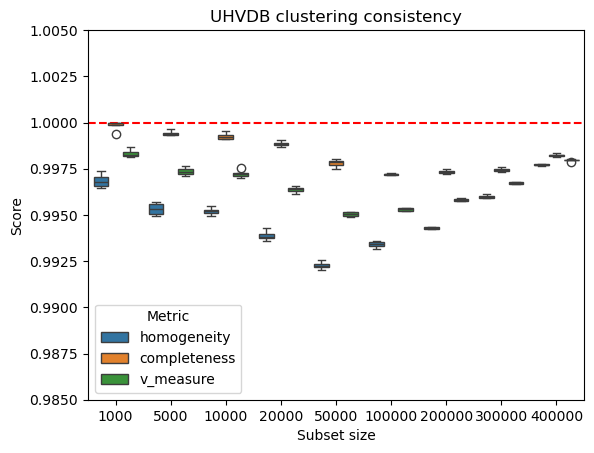

In [22]:
### Calculate cluster consistency across subsets
import seaborn as sns
import matplotlib.pyplot as plt

subset_results = (
    pl.from_dicts(results)
        .unpivot(index=["subset", "replicate", "num_sequences", "All clusters", "num_seqs_in_multi_seq_clusters", "Non-singleton clusters"], on=["homogeneity", "completeness", "v_measure"], variable_name="Metric", value_name="score")
        .filter(pl.col("subset") != "458383")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
ax = sns.boxplot(x="subset", y="score", data=subset_results, hue="Metric")
# plt.ylim(0.95, 1.01)
plt.title("UHVDB clustering consistency")
plt.xlabel("Subset size")
plt.ylabel("Score")
plt.ylim(0.985, 1.005)
# add horizontal line at y=1
plt.axhline(y=1, color='r', linestyle='--', label='Perfect Score')
plt.show()

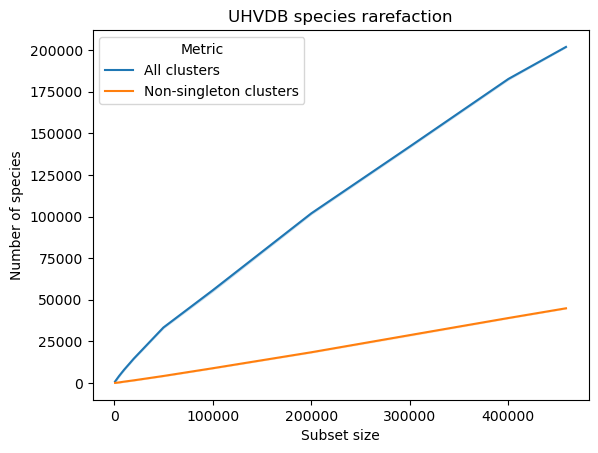

In [23]:
### Create rarefaction plot of number of clusters identified per subset
import seaborn as sns
import matplotlib.pyplot as plt

subset_cluster_counts = (
    pl.from_dicts(results)
        .with_columns([pl.col("subset").cast(pl.Int32)])
        .unpivot(index=["subset", "replicate"], on=["All clusters", "Non-singleton clusters"], variable_name="metric", value_name="value")
)

# create a rarefaction plot for number of clusters identified per subset
sns.lineplot(x="subset", y="value", hue='metric', data=subset_cluster_counts, markers=True, errorbar='sd')
plt.title("UHVDB species rarefaction")
plt.xlabel("Subset size")
plt.ylabel("Number of species")
plt.legend(title='Metric', loc='upper left')
plt.show()